In [1]:
using DifferentialEquations, LinearAlgebra, Random
using ForwardDiff, Zygote
using Lux, ComponentArrays, SciMLSensitivity, Optimisers
using CUDA, cuDNN
using ProgressBars, Plots

In [2]:
# In-place mutating function for speed during simulation
function nri_spring_physics!(dx, x, p, t)
    k, L = p # stiffness, rest length
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 # Avoid singularity if they perfectly overlap
                    # Force is proportional to (1 - L/dist)
                    dx[:, i] .+= -k * (1.0 - L/dist) .* r_ij
                end
            end
        end
    end
end

function swirling_spring_physics!(dx, x, p, t)
    k, L, swirl_strength = p # added swirl parameter
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 
                    # Standard push/pull
                    spring_force = -k * (1.0 - L/dist) .* r_ij
                    
                    # The magic trick: Orthogonal vector for 2D rotation (-y, x)
                    r_perp = [-r_ij[2], r_ij[1]]
                    swirl_force = swirl_strength * r_perp / dist
                    
                    dx[:, i] .+= spring_force .+ swirl_force
                end
            end
        end
    end
end


function lj_physics!(dx, x, p, t)
    epsilon, sigma = p
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist_sq = sum(abs2, r_ij)
                
                if dist_sq > 1e-4
                    # LJ Force derivative
                    term = 24.0 * epsilon * (2.0 * (sigma^12) / (dist_sq^7) - (sigma^6) / (dist_sq^4))
                    dx[:, i] .+= term .* r_ij
                end
            end
        end
    end
end

# Rejection sampling to ensure particles don't spawn overlapping
function safe_lj_init(D, N, min_dist)
    x = zeros(Float32, D, N)
    for i in 1:N
        placed = false
        while !placed
            proposal = randn(Float32, D) .* 2.0f0 # Spread out over a 2D Gaussian
            if i == 1
                x[:, i] = proposal
                placed = true
            else
                # Check distance against all previously placed atoms
                dists = [norm(proposal - x[:, j]) for j in 1:(i-1)]
                if minimum(dists) > min_dist
                    x[:, i] = proposal
                    placed = true
                end
            end
        end
    end
    return x
end

# (Assuming `lj_physics!` and `safe_lj_init` from the previous block are already defined)

function run_long_md_simulation(model_type=:lennard_jones; N_atoms=10, T_total=5000, dt=0.05)
    D = 2
    tspan = (0.0, T_total * dt)
    t_save = range(tspan[1], tspan[2], length=T_total)
    
    println("Initializing simulation...")
    if model_type == :spring
        p = (0.01, 1.0) # k, L
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(nri_spring_physics!, x0, tspan, p)
    elseif model_type == :swirling_spring
        p = (0.01, 1.0, 0.05) # k, L, swirl_strength
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(swirling_spring_physics!, x0, tspan, p)
    else # :lennard_jones
        p = (0.10, 1.0) # epsilon, sigma
        min_spawn_dist = 1.7f0
        x0 = safe_lj_init(D, N_atoms, min_spawn_dist)
        prob = ODEProblem(lj_physics!, x0, tspan, p)
    end
    
    println("Solving ODE...")
    sol = solve(prob, Tsit5(), saveat=t_save, reltol=1e-4, abstol=1e-4)
    
    # Preallocate and pack into a contiguous D x N x T array
    trajectory = zeros(Float32, D, N_atoms, T_total)
    for t in 1:T_total
        trajectory[:, :, t] = sol.u[t]
    end
    
    println("Trajectory generation complete. Shape: ", size(trajectory))
    return trajectory
end

function sample_training_batch(trajectory; batch_size=32, burn_in=1000)
    T_total = size(trajectory, 3)
    
    if burn_in >= T_total
        error("Burn-in period ($burn_in) must be less than total time steps ($T_total).")
    end
    
    # The valid range of frames after the system has equilibrated
    valid_indices = (burn_in + 1):T_total
    
    # Randomly select frames
    sample_indices = rand(valid_indices, batch_size)
    
    # Extract the slices into our desired (D, N, B) tensor shape
    batch = trajectory[:, :, sample_indices]
    return batch
end

function visualize_trajectory(trajectory; filename="md_simulation.mp4", fps=30, skip_frames=1)
    D, N, T = size(trajectory)
    
    println("Generating animation...")
    
    # Calculate global axis limits to keep the camera steady
    x_min, x_max = minimum(trajectory[1,:,:]), maximum(trajectory[1,:,:])
    y_min, y_max = minimum(trajectory[2,:,:]), maximum(trajectory[2,:,:])
    
    # Add a 10% padding to the boundaries so particles don't ride the edge
    pad_x = (x_max - x_min) * 0.1
    pad_y = (y_max - y_min) * 0.1
    xlims = (x_min - pad_x, x_max + pad_x)
    ylims = (y_min - pad_y, y_max + pad_y)
    
    # Generate the frames
    anim = @animate for t in 1:skip_frames:T
        scatter(
            trajectory[1, :, t], 
            trajectory[2, :, t], 
            xlims=xlims, ylims=ylims,
            legend=false, 
            framestyle=:box,
            markersize=8,
            markercolor=:royalblue,
            markerstrokecolor=:white,
            markerstrokewidth=1.5,
            aspect_ratio=:equal, # Keeps circles looking circular
            title="MD Simulation | Frame: $t"
        )
    end
    
    # Save the file (Plots.jl automatically determines format from the extension)
    if endswith(filename, ".mp4")
        mp4(anim, filename, fps=fps)
    else
        gif(anim, filename, fps=fps)
    end
    
    println("Animation saved to $filename")
end


function generate_static_asymmetric_dataset(; n_samples=1000, noise_std=0.1)
    # 1. Define an asymmetric "base" conformation of 10 points (2D)
    # Row 1: X coordinates | Row 2: Y coordinates
    # Shape: 2 x 10 (Dims x Particles)
    base_conformation = [
    # X coordinates (moving steadily left to right)
        0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5  4.0  4.5;
        
        # Y coordinates (steep drop to 0.0, then a steady climb)
        2.0  1.0  0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5
    ]
    
    # 2. Reshape to allow broadcasting across the sample dimension
    # Shape becomes: 2 x 10 x 1
    base_3d = reshape(base_conformation, 2, 10, 1)
    
    # 3. Generate Gaussian noise (jitter) for all samples
    # Shape: 2 x 10 x 1000
    noise = randn(2, 10, n_samples) .* noise_std
    
    # 4. Add the noise to the base conformation using broadcasting
    # Shape: 2 x 10 x 1000
    dataset = base_3d .+ noise
    
    return dataset
end

generate_static_asymmetric_dataset (generic function with 1 method)

In [3]:
# 1. Run a long simulation (e.g., 5000 frames)
#trajectory = run_long_md_simulation(:lennard_jones, N_atoms=20, T_total=4000)
trajectory = generate_static_asymmetric_dataset(n_samples=4000, noise_std=0.1)

# 2. Visualize the whole thing (skipping every 2nd frame to speed up the video)
visualize_trajectory(trajectory, filename="static_asym.mp4", fps=60, skip_frames=2)

# 3. Pull a training batch inside your training loop
# Discard the first 1000 frames where particles are aggressively pushing apart
train_data = sample_training_batch(trajectory, batch_size=1000, burn_in=0)

println("Training batch ready. Shape: ", size(train_data))

Generating animation...


┌ Info: Saved animation to /orcd/home/002/rsmukk/data/18337/juliaproj/RM_notebooks/static_asym.mp4
└ @ Plots /home/rsmukk/.julia/packages/Plots/GIume/src/animation.jl:156


Animation saved to static_asym.mp4
Training batch ready. Shape: (2, 10, 1000)


In [ ]:
# ======================================================================
# 1. ARCHITECTURE: The Arbitrary Edge Network
# ======================================================================
using Flux, ForwardDiff, Zygote, LinearAlgebra, ComponentArrays

struct EGNN_2Layer
    # Layer 1: The "Geometric Encoder"
    msg1::Chain   # Input: (h_i, h_j, d_ij^2, seq_dist) -> Vector
    node1::Chain  # Input: (h_i, aggregate_msg) -> New h_i
    
    # Layer 2: The "Force Head"
    msg2::Chain   # Input: (h_i_new, h_j_new, d_ij^2, seq_dist) -> Scalar weight
end

# Simple constructor
function EGNN_2Layer(h_dim::Int, hidden::Int, D_dim)
    # Layer 1: m_ij = MLP([h_i, h_j, d_ij^2, seq_dist, t]) -> (h_dim)
    #         h_i_new = h_i + MLP([h_i, aggregate_msg]) -> (h_dim)
    # Layer 2: w_ij = MLP([h_i_new, h_j_new, d_ij^2, seq_dist, t]) -> (D_dim)
    #          v_i = 1/N sum_j (x_i - x_j) * w_ij -> (D_dim)

    return EGNN_2Layer(
        Chain(Dense(2*h_dim + 3, hidden, swish), Dense(hidden, h_dim, swish)),
        Chain(Dense(2*h_dim, hidden, swish), Dense(hidden, h_dim)),
        Chain(Dense(2*h_dim + 3, hidden, swish), Dense(hidden, D_dim))
    )
end


# ======================================================================
# 2. VECTOR FIELD: Tensorized CNF Dynamics with Exact Trace
# ======================================================================
function get_pairwise_geometry(x)
    D, N, B = size(x)
    
    # Reshape for broadcasting: 
    # xi becomes (D, N, 1), xj becomes (D, 1, N)
    xi = reshape(x, D, N, 1, B)
    xj = reshape(x, D, 1, N, B)
    
    # Broadcasting subtraction creates a (D, N, N) tensor 
    # where diffs[:, i, j] = x_i - x_j
    diffs = xi .- xj # shape: (D, N, N, B)
    
    # Sum of squared differences along the spatial dimension
    d2 = sum(diffs.^2, dims=1) # shape: (1, N, N, B)
    d2_expand = reshape(d2, 1, N*N*B) # Flatten for MLP input
    
    return diffs, d2_expand
end



function layer1_update(x, hi_expand, hj_expand, seq_dist_expand, msg1, node1, mask)
    D, N, B = size(x)
    _, d2_expand = get_pairwise_geometry(x) #d2 is shape (1, N*N*B)
    
    # 2. Concatenate all edge features: [h_i, h_j, d_ij^2, seq_dist]
    # Result is (2*h_dim + 2, N, N)
    edge_inputs = vcat(hi_expand, hj_expand, d2_expand, seq_dist_expand)
    
    # 3. Flatten the N x N spatial dimensions into a batch dimension for Flux
    # Flux MLPs expect (features, batch_size). Here batch_size = N*N
    edge_inputs_flat = reshape(edge_inputs, size(edge_inputs, 1), N * N)
    
    # Pass through message network and reshape back to (hidden_dim, N, N)
    m_ij_flat = msg1(edge_inputs_flat)
    m_ij = reshape(m_ij_flat, size(m_ij_flat, 1), N, N)
    
    # 4. Aggregate messages (sum over j, which is dimension 3)
    # M_i is (hidden_dim, N, 1)
    M_i = sum(m_ij, dims=3)
    M_i_flat = reshape(M_i, size(M_i, 1), N)
    
    # 5. Update node features (Residual connection)
    node_inputs = vcat(h, M_i_flat)
    h_new = h .+ node1(node_inputs)
    
    return h_new
end



function layer2_velocity(x, h_new, msg2, seq_dist)
    N = size(x, 2)
    diffs, d2 = get_pairwise_geometry(x)
    
    # 1. Expand the updated node features
    hi = reshape(h_new, size(h_new, 1), N, 1)
    hj = reshape(h_new, size(h_new, 1), 1, N)
    hi_expand = repeat(hi, 1, 1, N)
    hj_expand = repeat(hj, 1, N, 1)
    seq_dist_expand = reshape(seq_dist, 1, N, N)
    
    # 2. Concatenate edge inputs using h_new
    edge_inputs = vcat(hi_expand, hj_expand, d2, seq_dist_expand)
    edge_inputs_flat = reshape(edge_inputs, size(edge_inputs, 1), N * N)
    
    # 3. Calculate scalar weights (pull/push force)
    # Output is (1, N*N)
    w_ij_flat = msg2(edge_inputs_flat)
    
    # Reshape back to (1, N, N)
    w_ij = reshape(w_ij_flat, 1, N, N)
    
    # 4. Compute final velocities: sum_j (x_i - x_j) * w_ij
    # diffs is (2, N, N), w_ij is (1, N, N)
    # Broadcasting multiplies the scalar weight across the X and Y coordinates
    weighted_diffs = diffs .* w_ij
    
    # Sum over j to get final velocity vector for each node i
    v_i = sum(weighted_diffs, dims=3) # shape: (2, N, 1)
    
    # Return as flat (2, N) matrix
    return reshape(v_i, 2, N)
end



function get_velocity(x_flat, p, t, h_initial, seq_dist_matrix)
    # 1. Reshape x_flat back to (2, N)
    N = size(h_initial, 2)
    x = reshape(x_flat, 2, N)
    
    # 2. Layer 1: Encode Geometry into Node Features
    # Compute all pairwise squared distances
    # h_initial is your one-hot matrix
    h_new = layer1_update(x, h_initial, p.msg1, p.node1, seq_dist_matrix)
    
    # 3. Layer 2: Compute Equivariant Velocities
    v = layer2_velocity(x, h_new, p.msg2, seq_dist_matrix)
    
    return vec(v) # Return as flat vector for ODE compatibility
end



function hutchinson_trace(f, x, eps_probe)
    # f is the velocity function: x -> dx/dt
    # eps_probe is a random vector of same size as x (e.g. Rademacher ±1)
    
    # ForwardDiff.derivative handles the inner JVP
    jvp = ForwardDiff.derivative(α -> f(x + α .* eps_probe), 0.0)
    
    # Dot product gives the trace estimate
    return dot(eps_probe, jvp)
end



function ode_dynamics(u, p, t)
    # u contains [x_flat..., logp]
    x_flat = u[1:end-1]
    
    # We need a random probe. For training, we usually 
    # sample one per step to keep it stochastic but consistent.
    # Note: In a real training loop, you might pass eps in via p
    eps_probe = p.eps_buffer 
    
    # Define a closure for the velocity field x -> dx/dt
    f_x = (xt) -> get_velocity(xt, p.net, t, p.h_fixed, p.seq_dists)
    
    dx_dt = f_x(x_flat)
    
    # Exact Trace or Hutchinson? 
    # Since N=10, x_flat is only 20 elements. 
    # ForwardDiff.jacobian(f_x, x_flat) is actually very fast!
    # But here is the Hutchinson version:
    dlogp_dt = -hutchinson_trace(f_x, x_flat, eps_probe)
    
    return vcat(dx_dt, dlogp_dt)
end

egnn_dynamics_tensorized (generic function with 1 method)

In [6]:
# ======================================================================
# 3. SETUP & INITIALIZATION
# ======================================================================
# Configuration
USE_GPU = true # Set to true and ensure `using CUDA` is added above if using NVIDIA GPUs
N_atoms = 10
B_size = 64
D_dim = 2
F_dim = N_atoms # Using one-hot encoding for atom identity as features
tspan = (0.0f0, 1.0f0)

# Setup device mapping (automatically handles GPU if requested and available)
dev = USE_GPU ? gpu_device() : cpu_device()

# Initialize Model
rng = Xoshiro(0)
edge_net = build_edge_network(F_dim, [32, 32])
p_net, st_net = Lux.setup(rng, edge_net)
#one hot encoding for particle identity
h_fixed = Matrix{Float32}(I, N_atoms, N_atoms)

# Align features with memory layout:
# h_i cycles 1..N repeatedly. h_j repeats each atom N times per block.
h_i_flat = repeat(h_fixed, outer=(1, N_atoms * B_size)) |> dev
h_j_flat = repeat(h_fixed, inner=(1, N_atoms), outer=(1, B_size)) |> dev

# The mask prevents self-interaction gradients. Shape: (1, N, N, 1) for broadcasting
cpu_mask = reshape(1.0f0 .- Matrix{Float32}(I, N_atoms, N_atoms), 1, N_atoms, N_atoms, 1)
# jvp probe selects d_ij component only for JVP
jvp_probe = vcat(zeros(Float32, 2 * F_dim, 1), ones(Float32, 1, 1), zeros(Float32, 1, 1))

# Move everything to the selected device
p = ComponentArray(p_net) |> dev
st = st_net |> dev
mask = cpu_mask |> dev
jvp_probe = jvp_probe |> dev

# Define the locked-in ODE closure
ode_func = (u, p, t) -> egnn_dynamics_tensorized(u, p, t; h_i_flat=h_i_flat, h_j_flat=h_j_flat, edge_net=edge_net, st=st, mask=mask, jvp_probe=jvp_probe)
u0_dummy = ComponentArray(x = zeros(Float32, D_dim, N_atoms, B_size), logp = zeros(Float32, 1, B_size)) |> dev
prob = ODEProblem(ode_func, u0_dummy, tspan, p)

ODEProblem with uType ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 1.0f0)
u0: ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}}(x = Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], logp = Float32[0.0 0.0 … 0.0 0.0])

In [7]:
# ======================================================================
# 4. LOSS FUNCTION & OPTIMIZATION
# ======================================================================
# Clean Gaussian Prior
function log_prior(x)
    # x shape: (D, N, B). We sum over D and N, leaving B.
    # log p(x) = -0.5 * ||x||^2 - (D*N/2)*log(2π)
    D, N, B = size(x)
    const_term = 0.5f0 * Float32(D * N) * log(2.0f0 * Float32(pi))
    s = sum(abs2, x, dims=(1,2)) # (1,1,B)
    lp = -0.5f0 .* reshape(s, 1, size(x,3)) .- const_term
    return lp
end

function nll_loss(params, x_batch, prob)
    # 1. Initialize u0: State x at data, logp at 0
    # Note: logp is (1, B) to match our dynamics output
    u0 = ComponentArray(x = x_batch, logp = zeros(Float32, 1, size(x_batch, 3))) |> dev
    
    # 2. Solve forward: data (t=0) -> noise (t=1)
    # We use a remake for the new parameters and starting batch
    _prob = remake(prob, p=params, u0=u0)
    sol = solve(_prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    
    # 3. Final outputs
    x_noise = sol.u[end].x
    delta_logp = sol.u[end].logp # ∫ -Trace dt
    
    # 4. Total NLL calculation
    # L = -log_prior(x_noise) + delta_logp
    # Note: delta_logp is (1, 1, B), log_prior is (1, B)
    log_pdata = log_prior(x_noise) .- delta_logp
    mean_nll = sum(-log_pdata) / size(x_batch, 3) 

    return mean_nll
end

function logp(params, x_batch, prob)
    # 1. Initialize u0: State x at data, logp at 0
    # Note: logp is (1, B) to match our dynamics output
    u0 = ComponentArray(x = x_batch, logp = zeros(Float32, 1, size(x_batch, 3))) |> dev
    
    # 2. Solve forward: data (t=0) -> noise (t=1)
    # We use a remake for the new parameters and starting batch
    _prob = remake(prob, p=params, u0=u0)
    sol = solve(_prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    
    # 3. Final outputs
    x_noise = sol.u[end].x
    delta_logp = sol.u[end].logp # ∫ -Trace dt
    
    # 4. Total NLL calculation
    # L = -log_prior(x_noise) + delta_logp
    # Note: delta_logp is (1, 1, B), log_prior is (1, B)
    log_pdata = log_prior(x_noise) .- delta_logp
    return log_pdata, x_noise
end

# Usage in training loop:
# val, grads = Zygote.withgradient(p -> nll_loss(p, x_batch, prob), p_net)

logp (generic function with 1 method)

In [8]:
# ======================================================================
# 4. TEST FORWARD & BACKWARD PASS
# ======================================================================
println("Starting forward and backward pass...")
x_batch = train_data[:, :, 1:B_size] # (D, N, B)
#loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch, prob), p)
loss, grads = Zygote.withgradient(nll_loss, p, x_batch, prob)

println("Loss: ", loss)
println("Calculated gradients successfully!")

Starting forward and backward pass...
Loss: 70.4479
Calculated gradients successfully!


In [8]:
# ======================================================================
# 5. OPTIMIZER
# ======================================================================
learning_rate = 1f-2
opt = Optimisers.Adam(learning_rate)
opt_state = Optimisers.setup(opt, p)

Leaf(Adam(eta=0.01, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999)))

In [9]:
# ======================================================================
# 6. TRAIN LOOP
# ======================================================================
function make_batch_prob(params, batch_size, tspan)
    h_i_flat_batch = repeat(h_fixed, outer=(1, N_atoms * batch_size)) |> dev
    h_j_flat_batch = repeat(h_fixed, inner=(1, N_atoms), outer=(1, batch_size)) |> dev

    ode_func_batch = (u, p, t) -> egnn_dynamics_tensorized(u, p, t;
        h_i_flat=h_i_flat_batch,
        h_j_flat=h_j_flat_batch,
        edge_net=edge_net,
        st=st,
        mask=mask,
        jvp_probe=jvp_probe)

    u0_dummy_batch = ComponentArray(
        x = zeros(Float32, D_dim, N_atoms, batch_size),
        logp = zeros(Float32, 1, batch_size)) |> dev

    return ODEProblem(ode_func_batch, u0_dummy_batch, tspan, params)
end

function train_adam(params, opt_state, prob, train_data;
                    epochs=25,
                    batch_size=B_size,
                    rng=Xoshiro(42))
    n_samples = size(train_data, 3)
    n_batches = cld(n_samples, batch_size)
    loss_history = Float32[]

    for epoch in 1:epochs
        shuffled_idx = randperm(rng, n_samples)
        epoch_loss = 0f0

        for (batch_num, batch_start) in enumerate(1:batch_size:n_samples)
            batch_stop = min(batch_start + batch_size - 1, n_samples)
            batch_idx = shuffled_idx[batch_start:batch_stop]
            x_batch = train_data[:, :, batch_idx]

            local_batch_size = length(batch_idx)
            batch_prob = local_batch_size == B_size ? prob : make_batch_prob(params, local_batch_size, tspan)

            loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch, batch_prob), params)
            grad_params = grads[1]
            grad_params === nothing && error("Zygote returned no gradient for the parameters.")

            opt_state, params = Optimisers.update(opt_state, params, grad_params)

            loss_f32 = Float32(loss)
            isfinite(loss_f32) || error("Non-finite loss at epoch=$epoch batch=$batch_num: $loss_f32")
            epoch_loss += loss_f32 * local_batch_size
            push!(loss_history, loss_f32)
        end

        @info "training" epoch batches=n_batches loss=(epoch_loss / n_samples)
    end

    return params, opt_state, loss_history
end


train_adam (generic function with 1 method)

In [10]:
n_epochs = 30
prob = make_batch_prob(p, B_size, tspan)
p, opt_state, loss_history = train_adam(p, opt_state, prob, train_data;
                                        epochs=n_epochs,
                                        batch_size=B_size)

# Keep `prob` synchronized with the latest parameters for later sampling/evaluation.
prob = remake(prob, p=p)

┌ Info: training
│   epoch = 1
│   batches = 16
│   loss = 66.09535
└ @ Main /home/rsmukk/data/18337/finalproj_test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:55
┌ Info: training
│   epoch = 2
│   batches = 16
│   loss = 35.556355
└ @ Main /home/rsmukk/data/18337/finalproj_test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:55
┌ Info: training
│   epoch = 3
│   batches = 16
│   loss = 15.825967
└ @ Main /home/rsmukk/data/18337/finalproj_test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:55
┌ Info: training
│   epoch = 4
│   batches = 16
│   loss = 11.769778
└ @ Main /home/rsmukk/data/18337/finalproj_test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:55
┌ Info: training
│   epoch = 5
│   batches = 16
│   loss = 9.168546
└ @ Main /home/rsmukk/data/18337/finalproj_test/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:55
┌ Info: trai

ODEProblem with uType ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 1.0f0)
u0: ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}}(x = Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], logp = Float32[0.0 0.0 … 0.0 0.0])

In [11]:
# ======================================================================
# 7. GENERATE SAMPLES FROM THE TRAINED MODEL
# ======================================================================
function generate_samples(n_samples=100)
    # 1. Initialize u0 with noise and zero logp
    u0 = ComponentArray(x = randn(Float32, D_dim, N_atoms, n_samples) |> dev, logp = zeros(Float32, 1, n_samples) |> dev)
    # 2. Solve backward: noise (t=1) -> data (t=0)
    prob = make_batch_prob(p, n_samples, (1.0f0, 0.0f0))
    prob = remake(prob, u0=u0) # Reverse time span for sampling
    sol = solve(prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    x_samples = sol.u[end].x
    return x_samples
end

generate_samples (generic function with 2 methods)

In [12]:
sample_1000 = generate_samples(1000) |> cpu_device()
#samples = randn(Float32, D_dim, N_atoms, 3)

2×10×1000 Array{Float32, 3}:
[:, :, 1] =
 -0.00333201  -1.01787   -1.79441  -2.08029  …  -3.31147  -3.49721  -4.10447
 -0.0600809   -0.679834  -1.06782  -1.60247     -3.92784  -4.37176  -4.85943

[:, :, 2] =
 0.622577  0.00878861  -0.802206  -0.382832  …  -2.61516  -2.93321  -3.30743
 0.210113  0.45424      0.163397   1.11862       2.46474   2.83369   3.3576

[:, :, 3] =
 -2.05626  -0.88262  0.0798153  …  -4.03324  -4.89106     -5.38096
 -1.19601  -0.37223  0.510023       0.44552  -0.00721977  -0.944652

;;; … 

[:, :, 998] =
  0.145107  -0.016568   0.429286  -0.31361  …  -2.9489   -3.33918  -3.9394
 -1.10334   -0.0239693  0.908307   1.03711      2.09616   2.36453   2.83466

[:, :, 999] =
 -0.109332  0.219443   0.037415   0.364875  …   1.37697   3.52308   -4.1116
  1.49344   0.453132  -0.537499  -0.622302     -1.73832  -0.904354   2.4799

[:, :, 1000] =
 0.42992   -0.455    -1.56305   -1.79557  …  -3.00045  -2.93451  -4.61328
 0.957745   0.70488   0.259962   1.00031      3.3045    3.77

In [13]:
# function to calculate all pairwise distances for a D x N x B tensor of positions
# i want a pairwise distance matrix for each batch element, so output should be (N, N, B)
function pairwise_distances(positions)
    D, N, B = size(positions)
    # Expand dimensions to compute pairwise differences via broadcasting
    pos_i = reshape(positions, D, N, 1, B)
    pos_j = reshape(positions, D, 1, N, B)
    r_ij = pos_i .- pos_j
    d_ij = sqrt.(sum(abs2, r_ij, dims=1))
    return reshape(d_ij, N, N, B)
end

pairwise_distances (generic function with 1 method)

In [14]:
train_data_dists = pairwise_distances(train_data);
gen_data_dists = pairwise_distances(sample_1000);

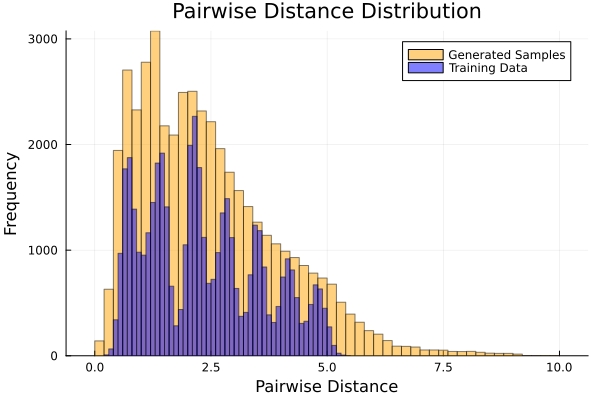

In [17]:
# Visualize the concordance of pairwise distance distributions between generated samples and training data
function visualize_distance_distributions(train_dists, gen_dists)
    # Flatten the upper triangle of the distance matrices to get 1D arrays of distances
    function upper_triangle_flat(dists)
        N = size(dists, 1)
        return [dists[i, j, b] for b in 1:size(dists, 3) for i in 1:N for j in (i+1):N]
    end
    train_flat = upper_triangle_flat(train_dists)
    gen_flat = upper_triangle_flat(gen_dists)
    # Plot histograms
    histogram(gen_flat, bins=50, alpha=0.5, label="Generated Samples", xlabel="Pairwise Distance", ylabel="Frequency", title="Pairwise Distance Distribution", color=:orange)
    histogram!(train_flat, bins=50, alpha=0.5, label="Training Data", color=:blue)

    #legend()
end

visualize_distance_distributions(train_data_dists, gen_data_dists)


In [ ]:
sample_1000

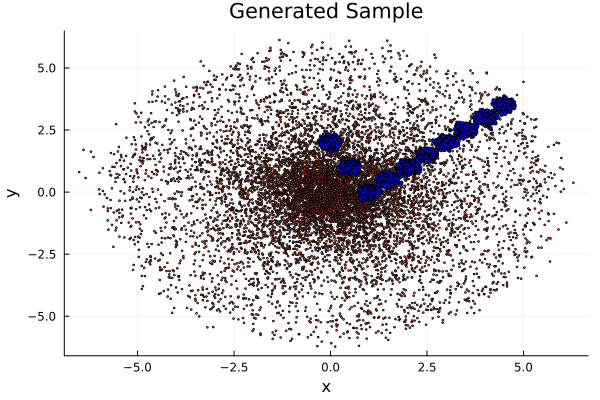

In [19]:
scatter(sample_1000[1, :, :], sample_1000[2, :, :], title="Generated Sample", xlabel="x", ylabel="y", markersize=1, markercolor=:tomato, legend=false)
scatter!(train_data[1, :, :], train_data[2, :, :], markersize=2, markercolor=:blue, legend=false)

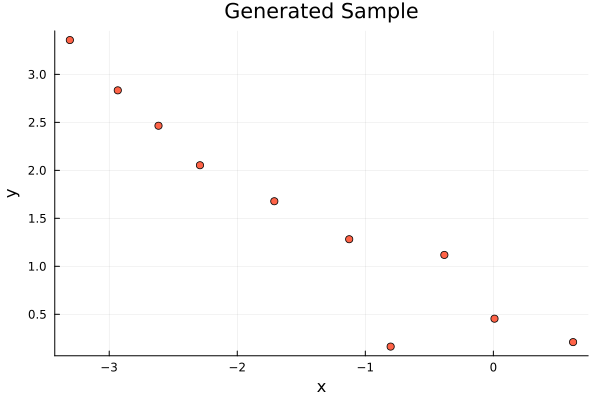

In [23]:
scatter(sample_1000[1, :, 2], sample_1000[2, :, 2], title="Generated Sample", xlabel="x", ylabel="y", markersize=4, markercolor=:tomato, legend=false)


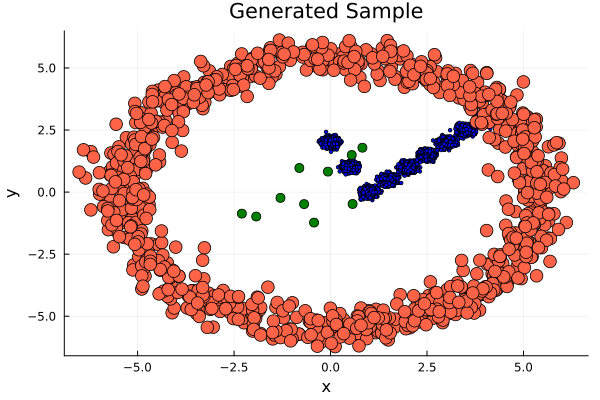

In [28]:
init_data = randn(Float32, D_dim, N_atoms, 1)
scatter(train_data[1, :, :], train_data[2, :, :], title="Generated Sample", xlabel="x", ylabel="y", markersize=2, markercolor=:blue, legend=false)
scatter!(sample_1000[1, 10, :], sample_1000[2, 10, :], markersize=7, markercolor=:tomato, legend=false)
scatter!(init_data[1, :, :], init_data[2, :, :], markersize=5, markercolor=:green, legend=false)